# Differentiable Rendering with jaxCAD's Parameter System

jaxCAD's sphere-tracing renderer is fully differentiable — gradients flow through the
march loop, normal computation, and shading. This notebook solves an **inverse-rendering
problem**: given a target photograph (`lada.png`), optimise a scene of SDF primitives so
its rendering minimises pixel-space MSE against the photo.

The full pipeline uses jaxCAD's parameter system end-to-end:

1. Build a `Scene` with geometry, per-primitive `Material`s (colours as free `Vector`
   params), and a `RenderConfig`.
2. `extract_parameters(scene)` yields one `free_params` dict covering geometry,
   materials, and render config — no manual bookkeeping.
3. `functionalize_render(scene)` compiles the scene to a pure
   `(free_params, resolution) → image` JAX function, differentiable via `jax.grad`.
4. Adam optimises `free_params` to minimise pixel-space MSE against the target.

Material colours are stored in `[0, 1]` linear space.  The background colour
(`bg_color`) is the exception: it lives in logit space and is sigmoid-mapped at
render time so it stays unconstrained during optimisation.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from PIL import Image

from jaxcad.extraction import extract_parameters
from jaxcad.geometry import Scalar, Vector
from jaxcad.render import Material, RenderConfig, Scene, functionalize_render
from jaxcad.sdf import Box, Sphere, Translate, Union

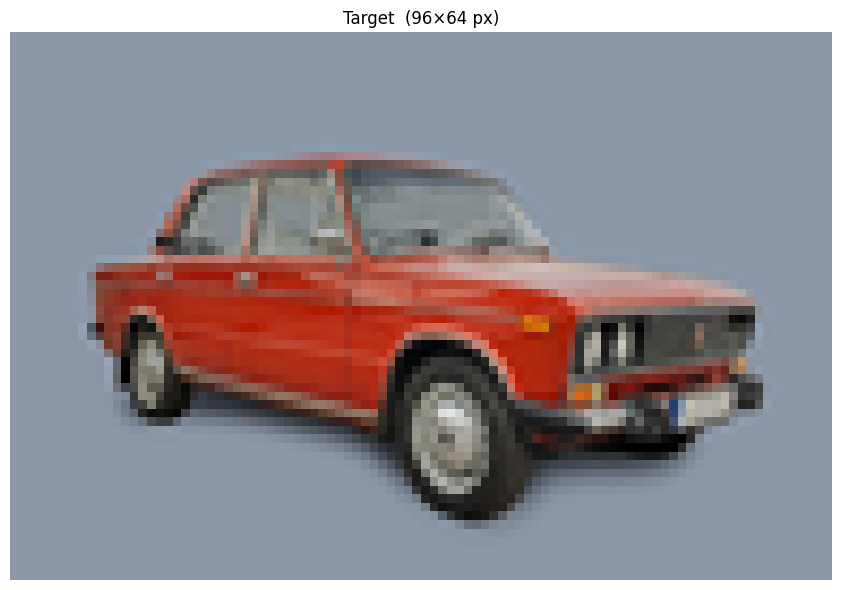

In [2]:
# ── Target image ─────────────────────────────────────────────────────────────
RES = (64, 96)  # (height, width)
SKY = (140, 152, 168)

img_rgba = Image.open("assets/lada.png").convert("RGBA")
bg = Image.new("RGB", img_rgba.size, SKY)
bg.paste(img_rgba.convert("RGB"), mask=img_rgba.split()[3])
target_pil = bg.resize((RES[1], RES[0]), Image.LANCZOS)

target = jnp.array(np.array(target_pil) / 255.0, dtype=jnp.float32)

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(np.array(target))
ax.set_title(f"Target  ({RES[1]}×{RES[0]} px)")
ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# ── Free geometry parameters ──────────────────────────────────────────────────
body_pos = Vector([0.0, -0.05, 0.0], free=True, name="body_pos")
roof_pos = Vector([-0.15, 0.72, 0.0], free=True, name="roof_pos")
r_roof = Scalar(0.6, free=True, name="r_roof")
wl_pos = Vector([-1.15, -0.68, 0.5], free=True, name="wl_pos")
wr_pos = Vector([1.15, -0.68, 0.5], free=True, name="wr_pos")
r_wheel = Scalar(0.40, free=True, name="r_wheel")  # shared → deduped

BODY_SIZE = jnp.array([1.85, 0.45, 0.72])  # fixed half-extents

# ── Material colours in [0, 1] space ─────────────────────────────────────────
# Passing a free Vector as color stores it in Material.params so
# extract_parameters finds it automatically via Primitive.children() → [material].
# The two wheels share one Vector object so extract_parameters deduplicates it.
col_wheel = Vector([0.12, 0.12, 0.12], free=True, name="col_wheel")

geometry = Union(
    (
        Translate(
            Box(
                size=BODY_SIZE,
                material=Material(
                    color=Vector([0.5, 0.5, 0.5], free=True, name="col_body"),
                    roughness=0.45,
                    metallic=0.05,
                ),
            ),
            offset=body_pos,
        ),
        Translate(
            Sphere(
                radius=r_roof,
                material=Material(
                    color=Vector([0.5, 0.5, 0.5], free=True, name="col_roof"),
                    roughness=0.45,
                    metallic=0.05,
                ),
            ),
            offset=roof_pos,
        ),
        Translate(
            Sphere(radius=r_wheel, material=Material(color=col_wheel, roughness=0.6)), offset=wl_pos
        ),
        Translate(
            Sphere(radius=r_wheel, material=Material(color=col_wheel, roughness=0.6)), offset=wr_pos
        ),
    ),
    smoothness=0.1,
)

# ── Render config ─────────────────────────────────────────────────────────────
render_cfg = RenderConfig(
    camera_pos=Vector([0.0, 0.6, 6.0], free=False, name="camera_pos"),
    look_at=Vector([0.0, 0.0, 0.0], free=False, name="look_at"),
    fov=Scalar(0.55, free=False, name="fov"),
    bg_color=Vector([0.1, 0.25, 0.55], free=True, name="bg_color"),
    light_dirs=[[0.45, 0.85, 0.25], [-0.3, 0.5, -0.2]],
    light_colors=[[0.95, 0.88, 0.75], [0.3, 0.38, 0.55]],
)

scene = Scene(geometry, render_cfg)

# ── Extract all free parameters in one shot ───────────────────────────────────
free_params, fixed_params, metadata = extract_parameters(scene)

print("free_params keys:", sorted(free_params.keys()))
print(
    f"\n{len(free_params)} free params, "
    f"{sum(v.size for v in free_params.values())} scalar values"
)

free_params keys: ['bg_color', 'body_pos', 'col_body', 'col_roof', 'col_wheel', 'r_roof', 'r_wheel', 'roof_pos', 'wl_pos', 'wr_pos']

10 free params, 26 scalar values


Rendering initial scene (first run triggers XLA compilation)...
Output shape: (64, 96, 3)


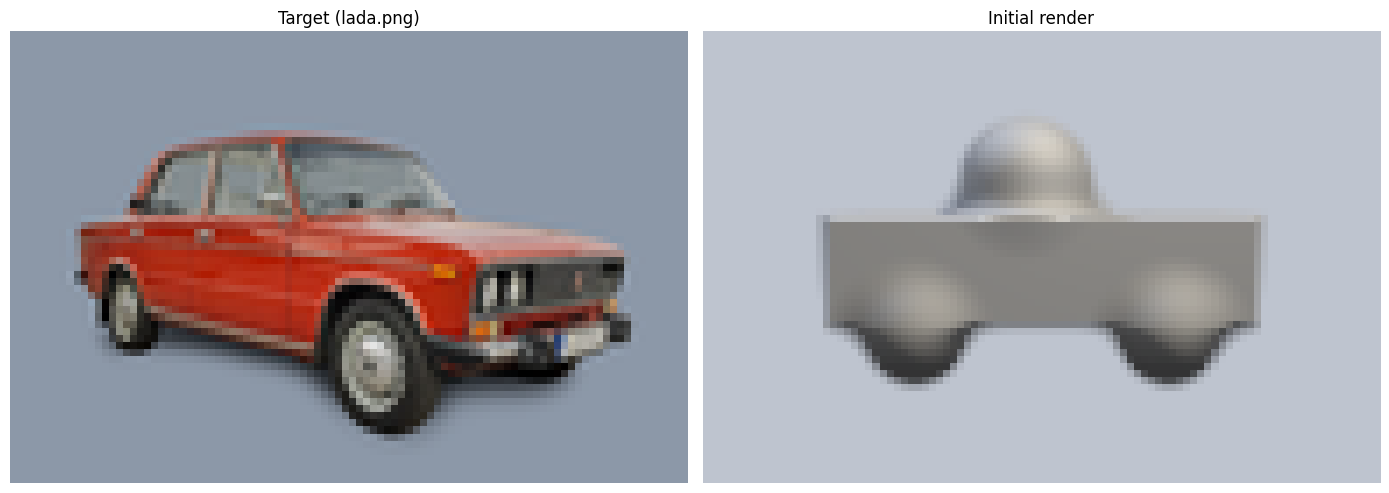

In [4]:
# ── Compile the scene to a differentiable render function ─────────────────────
#
# functionalize_render walks the geometry + material tree, builds pure JAX
# closures for the SDF and material_fn, and wires them into the sphere-tracing
# renderer. The result is a plain function that jax.grad can differentiate
# through entirely.

diff_render = functionalize_render(
    scene,
    max_steps=32,
    shadow_steps=12,
    shadow_hardness=6.0,
    gamma=2.2,
)

print("Rendering initial scene (first run triggers XLA compilation)...")
img0 = diff_render(free_params, resolution=RES)
print(f"Output shape: {img0.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(np.array(target))
axes[0].set_title("Target (lada.png)")
axes[0].axis("off")
axes[1].imshow(np.array(img0))
axes[1].set_title("Initial render")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Optimisation

We minimise mean-squared pixel error with Adam.  `jax.value_and_grad` differentiates
through the compiled render function — sphere-tracing, surface normals, shading, and
the softmax material blend — in one `jax.jit`-compiled call.

In [5]:
def loss_fn(free_params):
    return jnp.mean((diff_render(free_params, resolution=RES) - target) ** 2)


grad_fn = jax.jit(jax.value_and_grad(loss_fn))

N_STEPS = 200
LR = 0.04
optimizer = optax.adam(learning_rate=LR)
opt_state = optimizer.init(free_params)

params = free_params
losses = []
snapshots = {}

print(f"Optimising for {N_STEPS} steps (lr={LR}, Adam)")
print("First step triggers JIT compilation — may take a moment...")

for step in range(N_STEPS):
    val, grads = grad_fn(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    losses.append(float(val))

    if step in (0, 24, 49, 99, 149, 199):
        snapshots[step] = np.array(diff_render(params, resolution=RES))

    if step % 25 == 0 or step == N_STEPS - 1:
        print(f"  step {step:3d}/{N_STEPS-1}  |  loss = {val:.5f}")

Optimising for 200 steps (lr=0.04, Adam)
First step triggers JIT compilation — may take a moment...


ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape float32[]
slice start of jnp.mgrid
The error occurred while tracing the function loss_fn at /tmp/ipykernel_63567/2809754346.py:1 for jit. This value became a tracer due to JAX operations on these lines:

  operation a[35m:f32[3][39m = sub 1.0:f32[] b
    from line /home/ar/jaxcad/jaxcad/render/functionalize.py:216:13 (functionalize_render.<locals>.render_fn)

  operation a[35m:f32[][39m = mul 2.0:f32[] b
    from line /home/ar/jaxcad/jaxcad/render/functionalize.py:220:21 (functionalize_render.<locals>.render_fn)

  operation a[35m:f32[][39m = div b 64.0:f32[]
    from line /home/ar/jaxcad/jaxcad/render/functionalize.py:220:21 (functionalize_render.<locals>.render_fn)

  operation a[35m:f32[][39m = div b 96.0:f32[]
    from line /home/ar/jaxcad/jaxcad/render/raymarch.py:50:9 (_camera_rays)

  operation a[35m:f32[][39m = mul b 64.0:f32[]
    from line /home/ar/ja

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses, color="steelblue", linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE Loss")
ax.set_title("Pixel-space MSE over optimisation")
ax.set_yscale("log")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

In [ ]:
snap_steps = sorted(snapshots.keys())
n_cols = len(snap_steps) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3.5))

axes[0].imshow(np.array(target))
axes[0].set_title("Target")
axes[0].axis("off")

for ax, step in zip(axes[1:], snap_steps):
    ax.imshow(snapshots[step])
    ax.set_title(f"step {step}")
    ax.axis("off")

plt.suptitle("Optimisation trajectory", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
HIRES = (240, 360)
target_hires = np.array(target_pil.resize((HIRES[1], HIRES[0]), Image.LANCZOS)) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(target_hires)
axes[0].set_title("Target (lada.png)")
axes[0].axis("off")

axes[1].imshow(np.array(diff_render(free_params, resolution=HIRES)))
axes[1].set_title("Before optimisation")
axes[1].axis("off")

axes[2].imshow(np.array(diff_render(params, resolution=HIRES)))
axes[2].set_title(f"After {N_STEPS} steps")
axes[2].axis("off")

plt.suptitle("Inverse rendering: fitting SDF scene to a photograph", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.5f}")
print(f"Final loss:   {losses[-1]:.5f}")
print(f"Improvement:  {losses[0]/losses[-1]:.1f}\u00d7")